# Celestial Bodies in Scarabaeus
---
Last revised by Z. Ellis on 2026 APR 6

## Objectives
This tutorial will demonstrate 

## Imports and Set Up

Here we'll import the necessary libraries and load in the tutorials data folder. Then we define units and frames and load a metakernel for SPICE functionalities.

In [1]:
import scarabaeus as scb
from tutorial_data import tutorial_data

import os
import numpy as np
import matplotlib.pyplot as plt

# load tutorial data
data = tutorial_data.load()

## units, frames and kernels
km, AU, kg, sec, day, mu = scb.Units.get_units(['km', 'AU', 'kg', 
                                                'sec', 'day', 'mu'])
J2000, IAU_JUPITER = scb.Frame('J2000'), scb.Frame('IAU_JUPITER')

scb.SpiceManager.clear_kernels()    # ensure clean kernel pool
scb.SpiceManager.load_kernel_from_mkfile(data.mk)

SCB tutorial data up to date.


## Two Ways of Creating a Celestial Body
There are two different ways to create a celestial body in SCB. Generally, you'll only need to use the first of the two, which is quicker to do. Howeverm there are cases where you'll need more control over the body, which you should utilize the second method for.

### Using SCB-Defined Values
The first method creates a body using values defined within SCB's [Constants](https://ccar-orcca.github.io/scarabaeus-docs/scb_library/add_class_rsts/constants.html). Simply call:

In [2]:
jupiter_from_constants = scb.CelestialBody.from_constants('JUPITER')

### Using Your Own Values
If you want to define a body using values that differ from Scarabaeus' or that don't exist within its constants, you'll need to initialize it by providing more information:

In [3]:
jupiter_custom = scb.CelestialBody(name        = 'JUPITER_CUSTOM',
                                   mass        = scb.ArrayWUnits(1.9e27, kg),
                                   mean_radius = scb.ArrayWUnits(71000, km),
                                   grav_param  = scb.ArrayWUnits(1.3e8, mu),
                                   base_frame  = IAU_JUPITER,
                                   spice_id    = 599)

We can compare the two by displaying their properties.

In [4]:
jupiter_from_constants.disp_properties()
jupiter_custom.disp_properties()

                           JUPITER                            
mass                     : <bound method Body.mass of JUPITER>
mean_radius              : 71492.0 km
gravitational parameter  : 126686534.92180079 km^3/sec^2
reference frame          : IAU_JUPITER
SPICE ID                 : 599
attached ground stations : []
                            JUPITER_CUSTOM                           
mass                     : <bound method Body.mass of JUPITER_CUSTOM>
mean_radius              : 71000.0 km
gravitational parameter  : 130000000.0 km^3/sec^2
reference frame          : IAU_JUPITER (599 - JUPITER)
SPICE ID                 : 599
attached ground stations : []


# Querying Ephemerides
If the body exists within the kernel pool, you can query its ephemeris directly using ``get_state``. To illustrate this, we'll query the orbits of all the planets from the de432s we loaded at the top of this tutorial and plot them over a few years.

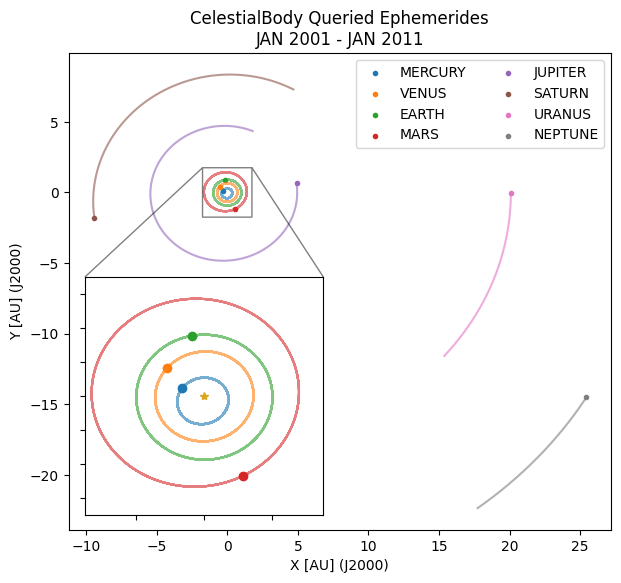

In [5]:
# 10 year time interval to examine
t0 = scb.EpochArray(scb.SpiceManager.cal2et('2001 JAN 01 00:00:00.000'), 'TDB')
tf = scb.EpochArray(scb.SpiceManager.cal2et('2011 JAN 01 00:00:00.000'), 'TDB')
dt = scb.ArrayWUnits(1, day)    # query once a day

epochs = scb.EpochArray.interval(t0, tf, dt)

# all the planets we want to query ephemerides for (recreating Jupiter for completion)
planets = dict.fromkeys(['MERCURY', 'VENUS', 'EARTH', 'MARS', 'JUPITER', 'SATURN', 'URANUS', 'NEPTUNE'])
for planet in planets:
    # create the body using its barycenter
    cb = scb.CelestialBody.from_constants(planet + '_BARYCENTER')
    
    # get its heliocentric state across time interval
    cb_states = []
    for epoch in epochs:
        state = cb.get_state(epoch_0         = epoch,
                             reference_frame = 'J2000',
                             origin          = 'SUN')
        cb_states.append(state[0:2].convert_to(AU).values)    # get 2D position in AU
    
    # save trajectory
    planets[planet] = np.array(cb_states)

## plot
fig, ax = plt.subplots(figsize = (7, 7))

# plot all trajectories
for planet in planets:
    ax.plot(planets[planet][:, 0], planets[planet][:, 1], alpha = 0.6)
    ax.scatter(planets[planet][-1, 0], planets[planet][-1, 1], 
               marker = '.', label = planet)

# zoom detail for inner planets
zoom_box, detail_bounds = [-1.75, 1.75, -1.75, 1.75], [0, 0.03, 0.5, 0.5]
det_ax = ax.inset_axes(detail_bounds, xlim = (zoom_box[0], zoom_box[1]),
                      ylim = (zoom_box[2], zoom_box[3]), xticklabels = [],
                      yticklabels = [])

# plot planets through Mars
for inner_planet in list(planets.keys())[:4]:
    det_ax.plot(planets[inner_planet][:, 0], planets[inner_planet][:, 1], alpha = 0.6)
    det_ax.scatter(planets[inner_planet][-1, 0], planets[inner_planet][-1, 1], 
                   marker = 'o')

det_ax.plot(0, 0, '*', color = 'goldenrod') # and the Sun
det_ax.set_aspect('equal')

# add zoom and final formatting
ax.indicate_inset_zoom(det_ax, edgecolor = 'k')
ax.legend(ncol = 2), ax.set_aspect('equal')
ax.set_xlabel('X [AU] (J2000)'), ax.set_ylabel('Y [AU] (J2000)')
ax.set_title('CelestialBody Queried Ephemerides\nJAN 2001 - JAN 2011')

plt.show()

## Conclusion
FILL OUT